In [1]:
import numpy as np
import pandas as pd
import sys

sys.path.insert(1, '../../src')

from FDEM import FDEM

# ------------------------------
# User parameters
# ------------------------------
n_models = 1000000          # number of conductivity models
n_layers = 9                # number of layers per model
sigma_min = 1e-3            # lower bound of conductivity range (S/m)
sigma_max = 1               # upper bound of conductivity range (S/m)
random_seed = 42            # reproducibility
tail_fraction = 0.02        # fraction of tail-augmented samples (optional)

# ------------------------------
# Derived log10 range
# ------------------------------
log10_min = np.log10(sigma_min)
log10_max = np.log10(sigma_max)
log10_range = log10_max - log10_min

# ------------------------------
# Latin Hypercube Sampling (LHS)
# ------------------------------
def lhs(n_samples, n_dims, rng):
    """
    Basic Latin Hypercube Sampling in [0,1].
    Returns array shape (n_samples, n_dims)
    """
    cut = np.linspace(0, 1, n_samples + 1)
    u = rng.random((n_samples, n_dims))
    pts = cut[:-1, None] + u * (1.0 / n_samples)

    # permute each dimension
    lhs_samples = np.zeros_like(pts)
    for j in range(n_dims):
        lhs_samples[:, j] = pts[rng.permutation(n_samples), j]
    return lhs_samples

# ------------------------------
# Generate LHS samples
# ------------------------------
rng = np.random.default_rng(random_seed)

lhs_unit = lhs(n_models, n_layers, rng)  # samples in [0,1]

# Map to log10(sigma)
log10_sigma = log10_min + lhs_unit * log10_range

# Convert to sigma
sigma = 10 ** log10_sigma

# ------------------------------
# Optional: tail augmentation
# ------------------------------
#n_tail = int(n_models * tail_fraction)

#if n_tail > 0:
#    half = n_tail // 2

    # strong lower-tail concentration (first 10% of log space)
#    low_tail_u = rng.random((half, n_layers)) * 0.1

    # strong upper-tail concentration (last 10%)
#    high_tail_u = 0.9 + rng.random((n_tail - half, n_layers)) * 0.1

#    tail_u = np.vstack([low_tail_u, high_tail_u])

    # map to log-space
#    tail_log10 = log10_min + tail_u * log10_range

    # overwrite random rows
#    tail_indices = rng.choice(n_models, n_tail, replace=False)
#    log10_sigma[tail_indices] = tail_log10
#    sigma[tail_indices] = 10 ** tail_log10

# ------------------------------
# Save to CSV files
# ------------------------------
log_cols = [f"log10_sigma_layer{i+1}" for i in range(n_layers)]
sigma_cols = [f"sigma_layer{i+1}" for i in range(n_layers)]

df_log = pd.DataFrame(log10_sigma, columns=log_cols)
df_sigma = pd.DataFrame(sigma, columns=sigma_cols)

df_log.to_csv("conductivity_models_log10.csv", index=False)
df_sigma.to_csv("conductivity_models_sigma.csv", index=False)

print("Done! Generated:")
print(f"  {n_models} models × {n_layers} layers")
print(f"  Conductivity range: {sigma_min} → {sigma_max} S/m")
print("Files written:")
print("  conductivity_models_log10.csv")
print("  conductivity_models_sigma.csv")


/tmp/ipykernel_3561216/3586275802.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Done! Generated:
  1000000 models × 9 layers
  Conductivity range: 0.001 → 1 S/m
Files written:
  conductivity_models_log10.csv
  conductivity_models_sigma.csv


In [3]:
# Extract random models
num = 400000
models = log10_sigma[np.random.choice(log10_sigma.shape[0], num, replace=False)]

In [4]:
h1 = np.logspace(-0.3,0.35,8)
print(h1)
print(np.cumsum(h1))

[0.50118723 0.62066484 0.76862461 0.95185639 1.17876863 1.4597743
 1.80776868 2.23872114]
[0.50118723 1.12185207 1.89047668 2.84233307 4.0211017  5.48087601
 7.28864468 9.52736582]


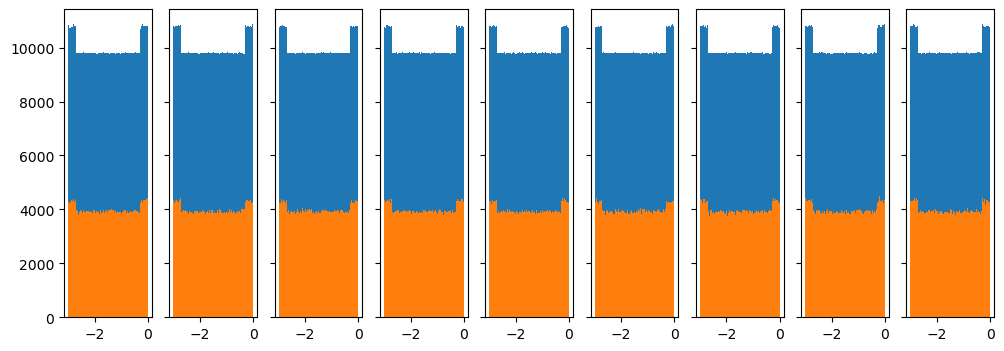

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,9, figsize =(12,4), sharey=True)

for i in range(9):
    ax[i].hist(log10_sigma[:,i], bins=100)
    ax[i].hist(models[:,i], bins=100)

In [6]:
# 2. Generate data

data = []

for m in models:
    data.append(FDEM(10**m, h1, height=0.47))

print('Done!')

Done!


In [8]:
data = np.array(data)

In [9]:
# Save models

np.save('Models/models_log_9layers_new400_field', models)
np.save('Data/data_9layers_new400_field', data)